# 1 - Imports

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parents[0].parents[0]))

In [3]:
from src.utils import config, io
from src.features import selection, pruning
from src.preprocessing import preprocess_pipeline
from src.models import model_pipeline, evaluate

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/pypdf/_crypt_providers/_cryptography.py:32: CryptographyDeprecationWarning: ARC4 has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.ARC4 and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  from cryptography.hazmat.primitives.ciphers.algorithms import AES, ARC4


In [4]:
import mlflow
import numpy as np
import pandas as pd
from itertools import product
import matplotlib.pyplot as plt
import seaborn as sns

from missingno import matrix as msno_matrix
from missingno import heatmap as msno_heatmap

sns.set_theme(style="whitegrid", context="talk")

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


# 2 - Preprocessing

In [5]:
split_cfg = io.load_json(config.PROCESSED_DATA_DIR / 'splits/temporal_v1.json')
split_cfg

{'description': 'Forecasting split for future country risk prediction',
 'train_years': [1999, 2017],
 'val_years': [2018, 2020],
 'test_years': [2021, 2024]}

In [6]:
def temporal_split(X, y, config):
    train_mask = (
        (X['YEAR'] >= config['train_years'][0]) &
        (X['YEAR'] <= config['train_years'][1])
    )

    val_mask = (
        (X['YEAR'] >= config['val_years'][0]) &
        (X['YEAR'] <= config['val_years'][1])
    )

    test_mask = (
        (X['YEAR'] >= config['test_years'][0]) &
        (X['YEAR'] <= config['test_years'][1])
    )

    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val     = X[val_mask], y[val_mask]
    X_test, y_test   = X[test_mask], y[test_mask]

    return X_train, y_train, X_val, y_val, X_test, y_test


In [7]:
def expanding_window_split(df, start_year, end_year, val_start_year):

    for val_year in range(val_start_year, end_year + 1):
        
        train_mask = (df['YEAR'] >= start_year) & (df['YEAR'] < val_year)
        val_mask = df['YEAR'] == val_year
        
        train_idx = df.index[train_mask]
        val_idx = df.index[val_mask]
        
        if len(val_idx) > 0:
            yield train_idx, val_idx


In [ ]:
# !mlflow server --port 500

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[2026-02-13 16:16:09 +0100] [21506] [INFO] Starting gunicorn 23.0.0
[2026-02-13 16:16:09 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:10 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:11 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:12 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:13 +0100] [21506] [ERROR] connection to ('127.0.0.1', 500) failed: [Errno 13] Permission denied
[2026-02-13 16:16:14 +0100] [21506] [ERROR] Can't connect

# 3 - Parameter Tuning for Dataset

## 3.1 - Parameter Tuning Feature Selection

### 3.1.1 - Run Parameter Cross Validation

In [8]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
# mlflow.create_experiment('Feature Selection Parameters')
mlflow.set_experiment('Feature Selection Parameters')

<Experiment: artifact_location='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349', creation_time=1770992451508, experiment_id='378044102522567349', last_update_time=1770992451508, lifecycle_stage='active', name='Feature Selection Parameters', tags={}>

In [9]:
dataset = io.load_csv(config.INTERIM_DATA_DIR / 'merged_dataset.csv', index_col=0)
dataset

,YEAR,ISO3_COUNTRY_CODE,OECD_RATING,GEO_REGION,ADMIN_REGION,LENDING_TYPE,INCOME_GROUP,NY.GDP.MKTP.CD,NY.GDP.MKTP.KD.ZG,NY.GDP.MKTP.PP.CD,...,SE.PRM.CUAT.ZS,SP.POP.DPND,SL.TLF.CACT.ZS,GE.EST,RQ.EST,IC.BRE.BI.OS,IC.BRE.BE.OS,IQ.CPA.PADM.XQ,FS.AST.PRVT.GD.ZS,FM.AST.PRVT.GD.ZS
COUNTRY_PERIOD_INDEX,,,,,,,,,,,,,,,,,,,,,
AFG-1999,1999,AFG,7,MEA,MNA,IDX,LIC,NaN,NaN,NaN,...,NaN,108.686031,46.609,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFG-2000,2000,AFG,7,MEA,MNA,IDX,LIC,3.521418e+09,NaN,1.637703e+10,...,NaN,109.586048,46.562,-2.173946,-2.080253,NaN,NaN,NaN,NaN,NaN
AFG-2001,2001,AFG,-,MEA,MNA,IDX,LIC,2.813572e+09,-9.431974,1.516633e+10,...,NaN,110.219341,46.526,NaN,NaN,NaN,NaN,NaN,NaN,NaN
AFG-2002,2002,AFG,-,MEA,MNA,IDX,LIC,3.825701e+09,28.600001,1.980700e+10,...,NaN,110.534611,46.505,-1.587687,-1.811546,NaN,NaN,NaN,NaN,NaN
AFG-2003,2003,AFG,-,MEA,MNA,IDX,LIC,4.520947e+09,8.832278,2.198200e+10,...,NaN,110.557540,46.497,-1.175768,-1.463108,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZWE-2019,2019,ZWE,7,SSF,SSA,IDB,LMC,3.335770e+10,-6.332450,6.361373e+10,...,75.001228,85.447906,65.795,-1.310435,-1.486515,NaN,NaN,3.0,3.428022,3.428022
ZWE-2020,2020,ZWE,7,SSF,SSA,IDB,LMC,3.198033e+10,-7.816951,6.488043e+10,...,NaN,84.384381,64.665,-1.342368,-1.434415,NaN,NaN,3.0,3.642132,3.642132
ZWE-2021,2021,ZWE,7,SSF,SSA,IDB,LMC,4.128767e+10,8.468017,7.625453e+10,...,NaN,83.384953,65.397,-1.290561,-1.386109,NaN,NaN,3.0,4.759522,4.759522


In [ ]:
def get_X_y(dataset):
    # Drop Instances with little data
    dataset = dataset[(dataset.isna().sum(axis=1) / len(dataset.columns)) <= 0.5]

    non_float_features_t = list(dataset.columns[dataset.dtypes!=float])
    non_float_features = []
    for c in non_float_features_t:
        if c != 'OECD_RATING':
            non_float_features.append(c)

    X = dataset.drop(columns=['OECD_RATING']) # Drop Target
    X = X.drop(columns=['ISO3_COUNTRY_CODE']) # Drop Country ID (maybe YEAR)
    y = dataset['OECD_RATING']

    return X, y

def transform_initial_dataset(dataset, feature_selection_params):

    dataset = selection.get_dataset_feature_selected(dataset, feature_selection_params)
    X, y = get_X_y(dataset)

    return X, y

In [19]:
feature_selection_grid = {
    'max_missing_ratio': [0.2, 0.3, 0.4, 0.5, 0.6],
    'low_var_threshold': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1],
    'max_corr': [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95],
    # 'top_k_mi': [25, 50, 100, 200]
}

In [ ]:
preprocessor_params = {
    'num_imputer': 'knn', 
    'cat_imputer': 'uni'
}

model_params = {
    'C': 1.0,
    'max_iter': 2000,
    'class_weight': 'balanced'
}

In [22]:
i = 0
for max_missing_ratio, low_var_threshold, max_corr in product( #top_k_mi
    feature_selection_grid['max_missing_ratio'], feature_selection_grid['low_var_threshold'], feature_selection_grid['max_corr'], # feature_selection_grid['top_k_mi'], 
):
    if i%10 == 0:
        print('Progress', str(round(100*i/(np.sum([len(vs) for vs in feature_selection_grid.items()])), 1)), '%')
    selected_params = {
        'max_missing_ratio': max_missing_ratio, 
        'low_var_threshold': low_var_threshold, 
        'max_corr': max_corr, 
        # 'top_k_mi': top_k_mi
    }
    X, y = transform_initial_dataset(dataset, selected_params)
    preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params) # Get Default pipeline
    

    cv_scores = {
        'accuracy': [],
        'precision': [],
        'recall': [],
        'f1': []
    }
    with mlflow.start_run():

        for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
            fold_prefix = 'fold_' + str(fold) + '_'

            X_train, y_train = X.loc[train_idx], y.loc[train_idx]
            X_val, y_val = X.loc[val_idx], y.loc[val_idx]
                        
            model = model_pipeline.get_model_pipeline('logistic_regression', preprocessor, model_params)
            model.fit(X_train, y_train)

            val_fold_results = evaluate.evaluate_model(model, X_val, y_val, prefix=fold_prefix, verbose=False)

            cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
            cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
            cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
            cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])

        mlflow.log_params(selected_params)
        print(selected_params)
        cv_mean_scores = {'cv_mean_' + k: np.mean(vs) for k, vs in cv_scores.items()}
        print(cv_mean_scores)
        mlflow.log_metrics(cv_mean_scores)

Final Dataset Shape: (4204, 23)
{'max_missing_ratio': 0.2, 'low_var_threshold': 1e-05, 'max_corr': 0.5}
{'accuracy': [0.5614035087719298, 0.5470588235294118, 0.5838150289017341, 0.5549132947976878, 0.5789473684210527, 0.5789473684210527], 'precision': [0.5662302443271879, 0.5445248976783696, 0.5252818195214509, 0.4872648055877869, 0.5185597523069109, 0.5336961305046412], 'recall': [0.5653578944994814, 0.5295759150410313, 0.5480527022338869, 0.5012121498715342, 0.49071936270683697, 0.48785203384437315], 'f1': [0.5415274033239188, 0.5117641488447149, 0.5215955869527298, 0.4819255932037887, 0.4892962325716537, 0.4822094199838102]}
Final Dataset Shape: (4204, 26)
{'max_missing_ratio': 0.2, 'low_var_threshold': 1e-05, 'max_corr': 0.6}
{'accuracy': [0.5321637426900585, 0.5588235294117647, 0.5606936416184971, 0.5722543352601156, 0.631578947368421, 0.5789473684210527], 'precision': [0.5381986529522683, 0.5556830616682833, 0.4928053830227744, 0.4972345575133032, 0.5529591836734694, 0.5320861678

### 3.1.2 - Analysis of Params Results

In [26]:
e = mlflow.set_experiment('Feature Selection Parameters')
e.experiment_id

'378044102522567349'

In [27]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id

In [28]:
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

881

In [29]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)

In [30]:
df = pd.DataFrame(rows)
df = df.astype(float)
df

,max_corr,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall,top_k_mi
0,0.95,0.10000,0.6,0.622677,0.613550,0.668604,0.623602,NaN
1,0.90,0.10000,0.6,0.598040,0.588148,0.653830,0.602913,NaN
2,0.85,0.10000,0.6,0.597304,0.590028,0.660635,0.602812,NaN
3,0.80,0.10000,0.6,0.597893,0.588325,0.662489,0.600473,NaN
4,0.70,0.10000,0.6,0.571142,0.555389,0.618151,0.565337,NaN
...,...,...,...,...,...,...,...,...
876,0.60,0.00001,0.2,0.519667,0.500709,0.570467,0.518946,25.0
877,0.50,0.00001,0.2,0.527373,0.501970,0.566630,0.519035,200.0
878,0.50,0.00001,0.2,0.527373,0.501970,0.566630,0.519035,100.0
879,0.50,0.00001,0.2,0.527373,0.501970,0.566630,0.519035,50.0


In [35]:
df_clean = df[df['top_k_mi'].isna()].drop(columns=['top_k_mi']).dropna()
df_clean

,max_corr,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.95,0.10000,0.6,0.622677,0.613550,0.668604,0.623602
1,0.90,0.10000,0.6,0.598040,0.588148,0.653830,0.602913
2,0.85,0.10000,0.6,0.597304,0.590028,0.660635,0.602812
3,0.80,0.10000,0.6,0.597893,0.588325,0.662489,0.600473
4,0.70,0.10000,0.6,0.571142,0.555389,0.618151,0.565337
...,...,...,...,...,...,...,...
170,0.85,0.00001,0.2,0.549143,0.530188,0.611795,0.543518
171,0.80,0.00001,0.2,0.549143,0.530188,0.611795,0.543518
172,0.70,0.00001,0.2,0.538319,0.516330,0.587966,0.533325
173,0.60,0.00001,0.2,0.528161,0.507130,0.572410,0.524678


In [40]:
df_clean.sort_values(by=['cv_mean_f1', 'cv_mean_accuracy'], ascending=False).head(20)

,max_corr,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.95,0.10000,0.6,0.622677,0.613550,0.668604,0.623602
7,0.95,0.01000,0.6,0.622677,0.613550,0.668604,0.623602
14,0.95,0.00100,0.6,0.622677,0.613550,0.668604,0.623602
21,0.95,0.00010,0.6,0.622677,0.613550,0.668604,0.623602
28,0.95,0.00001,0.6,0.622677,0.613550,0.668604,0.623602
70,0.95,0.10000,0.4,0.612801,0.603092,0.663257,0.613101
77,0.95,0.01000,0.4,0.612801,0.603092,0.663257,0.613101
84,0.95,0.00100,0.4,0.612801,0.603092,0.663257,0.613101
91,0.95,0.00010,0.4,0.612801,0.603092,0.663257,0.613101
98,0.95,0.00001,0.4,0.612801,0.603092,0.663257,0.613101


#### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

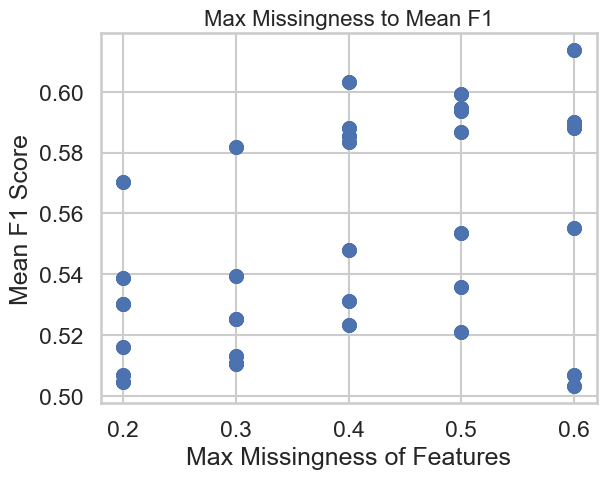

In [41]:
plt.scatter(df_clean['max_missing_ratio'], df_clean['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

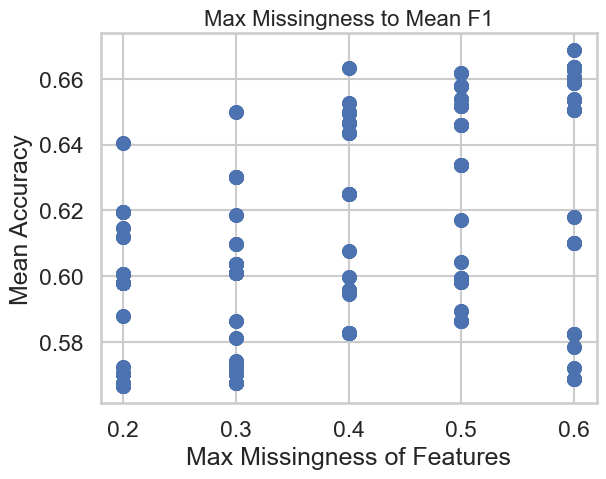

In [42]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

#### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

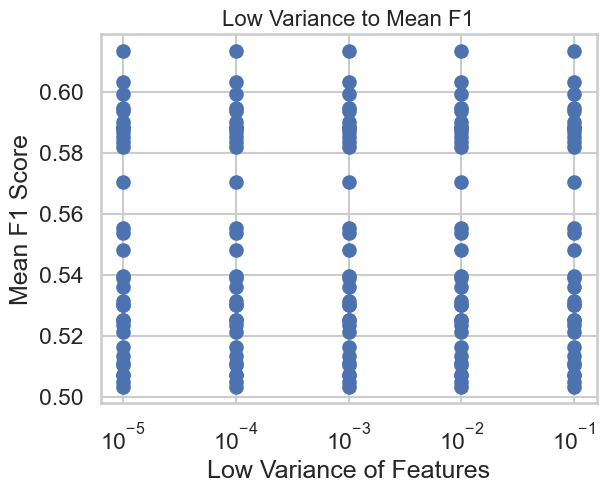

In [43]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_clean['low_var_threshold'], df_clean['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

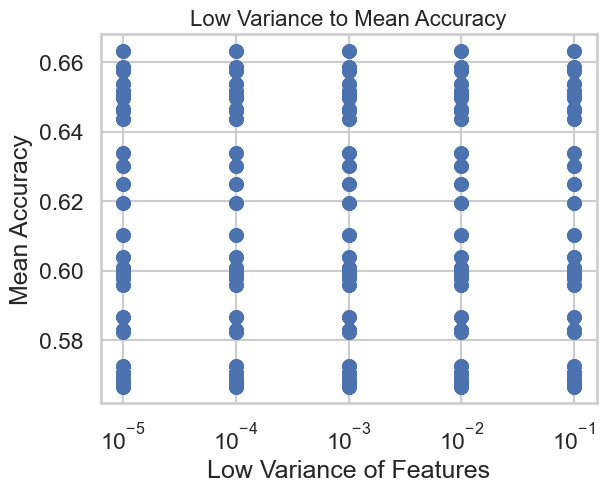

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


#### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

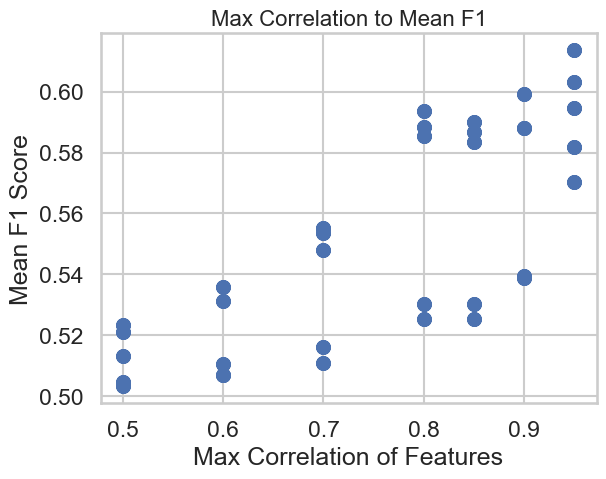

In [44]:
plt.scatter(df_clean['max_corr'], df_clean['cv_mean_f1'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

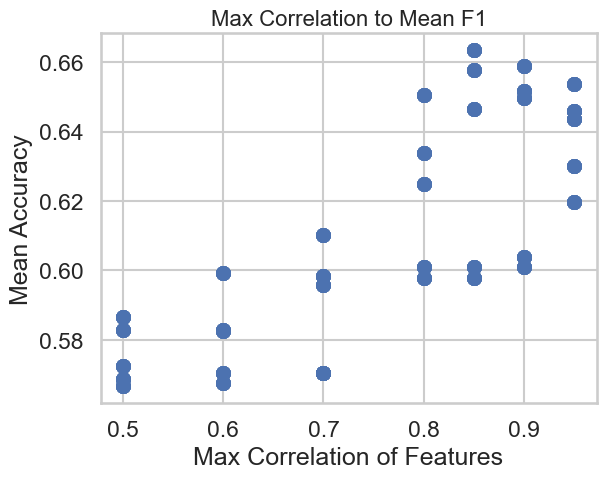

In [ ]:
plt.scatter(df['max_corr'], df['cv_mean_accuracy'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean Accuracy')

Best max_corr: 0.95

#### Set Subset For better View

In [ ]:
df_subset = df[df['max_corr'] == 0.95]
df_subset = df_subset.drop(columns=['top_k_mi', 'max_corr']).drop_duplicates()
df_subset

,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.10000,0.6,0.617672,0.605014,0.653633,0.617945
28,0.01000,0.6,0.617672,0.605014,0.653633,0.617945
56,0.00100,0.6,0.617672,0.605014,0.653633,0.617945
84,0.00010,0.6,0.617672,0.605014,0.653633,0.617945
112,0.00001,0.6,0.617672,0.605014,0.653633,0.617945
140,0.10000,0.5,0.612374,0.597240,0.645896,0.610022
168,0.01000,0.5,0.612374,0.597240,0.645896,0.610022
196,0.00100,0.5,0.612374,0.597240,0.645896,0.610022
224,0.00010,0.5,0.612374,0.597240,0.645896,0.610022
252,0.00001,0.5,0.612374,0.597240,0.645896,0.610022


#### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

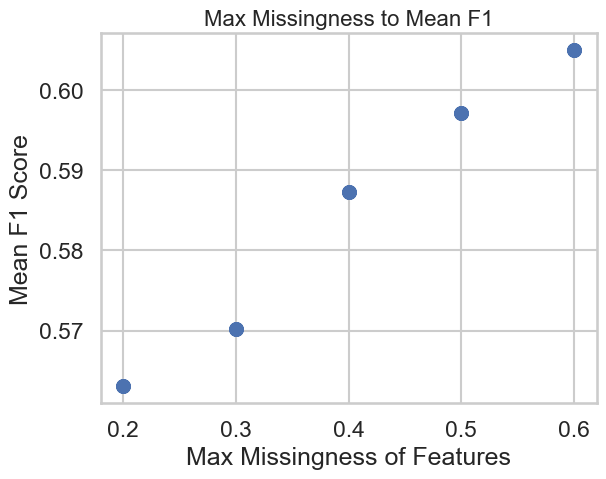

In [ ]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

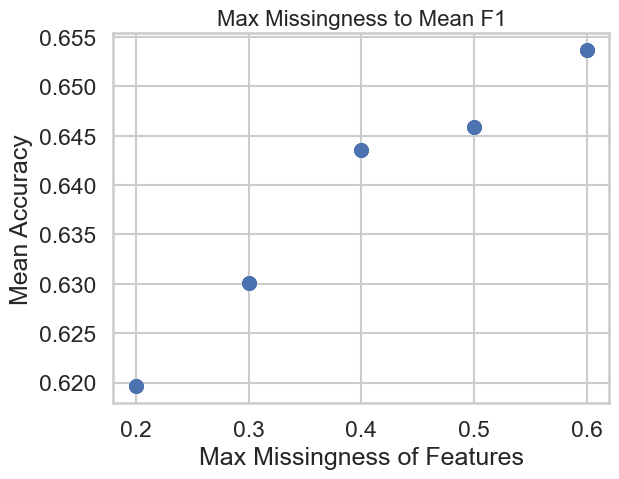

In [ ]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

Best max_missing_ratio: 0.6

#### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

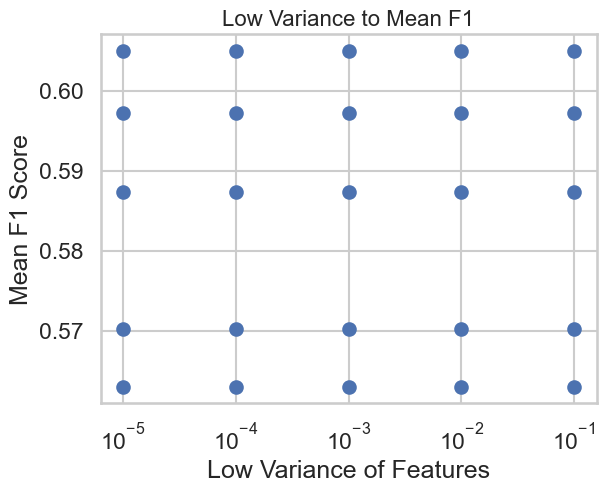

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

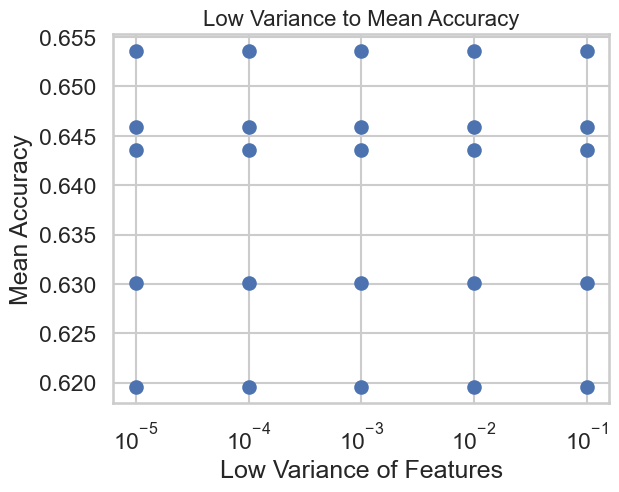

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


#### Correlation

In [ ]:
df.corr()

,max_corr,low_var_threshold,max_missing_ratio,top_k_mi,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
max_corr,1.000000e+00,1.187805e-17,-1.346650e-15,2.039939e-17,8.047031e-01,7.852137e-01,7.799878e-01,7.889775e-01
low_var_threshold,1.187805e-17,1.000000e+00,2.191037e-16,1.889756e-16,1.676826e-15,5.705914e-16,3.340624e-15,-2.126166e-15
max_missing_ratio,-1.346650e-15,2.191037e-16,1.000000e+00,6.200501e-16,4.286773e-01,4.620288e-01,4.843349e-01,4.382495e-01
top_k_mi,2.039939e-17,1.889756e-16,6.200501e-16,1.000000e+00,2.401401e-16,2.885995e-16,4.131479e-16,1.910585e-16
cv_mean_precision,8.047031e-01,1.676826e-15,4.286773e-01,2.401401e-16,1.000000e+00,9.944943e-01,9.842894e-01,9.905960e-01
cv_mean_f1,7.852137e-01,5.705914e-16,4.620288e-01,2.885995e-16,9.944943e-01,1.000000e+00,9.894790e-01,9.981645e-01
cv_mean_accuracy,7.799878e-01,3.340624e-15,4.843349e-01,4.131479e-16,9.842894e-01,9.894790e-01,1.000000e+00,9.849867e-01
cv_mean_recall,7.889775e-01,-2.126166e-15,4.382495e-01,1.910585e-16,9.905960e-01,9.981645e-01,9.849867e-01,1.000000e+00


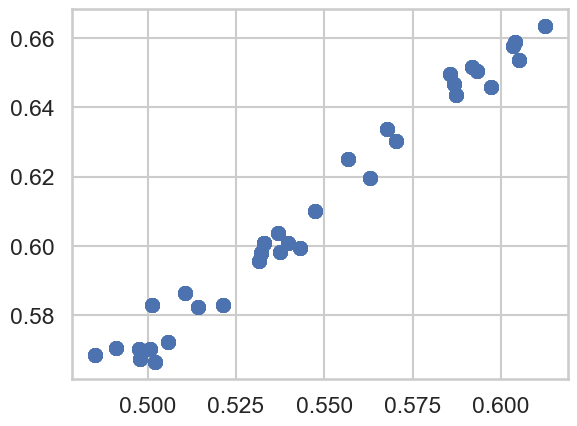

In [173]:
plt.scatter(df['cv_mean_f1'], df['cv_mean_accuracy'])

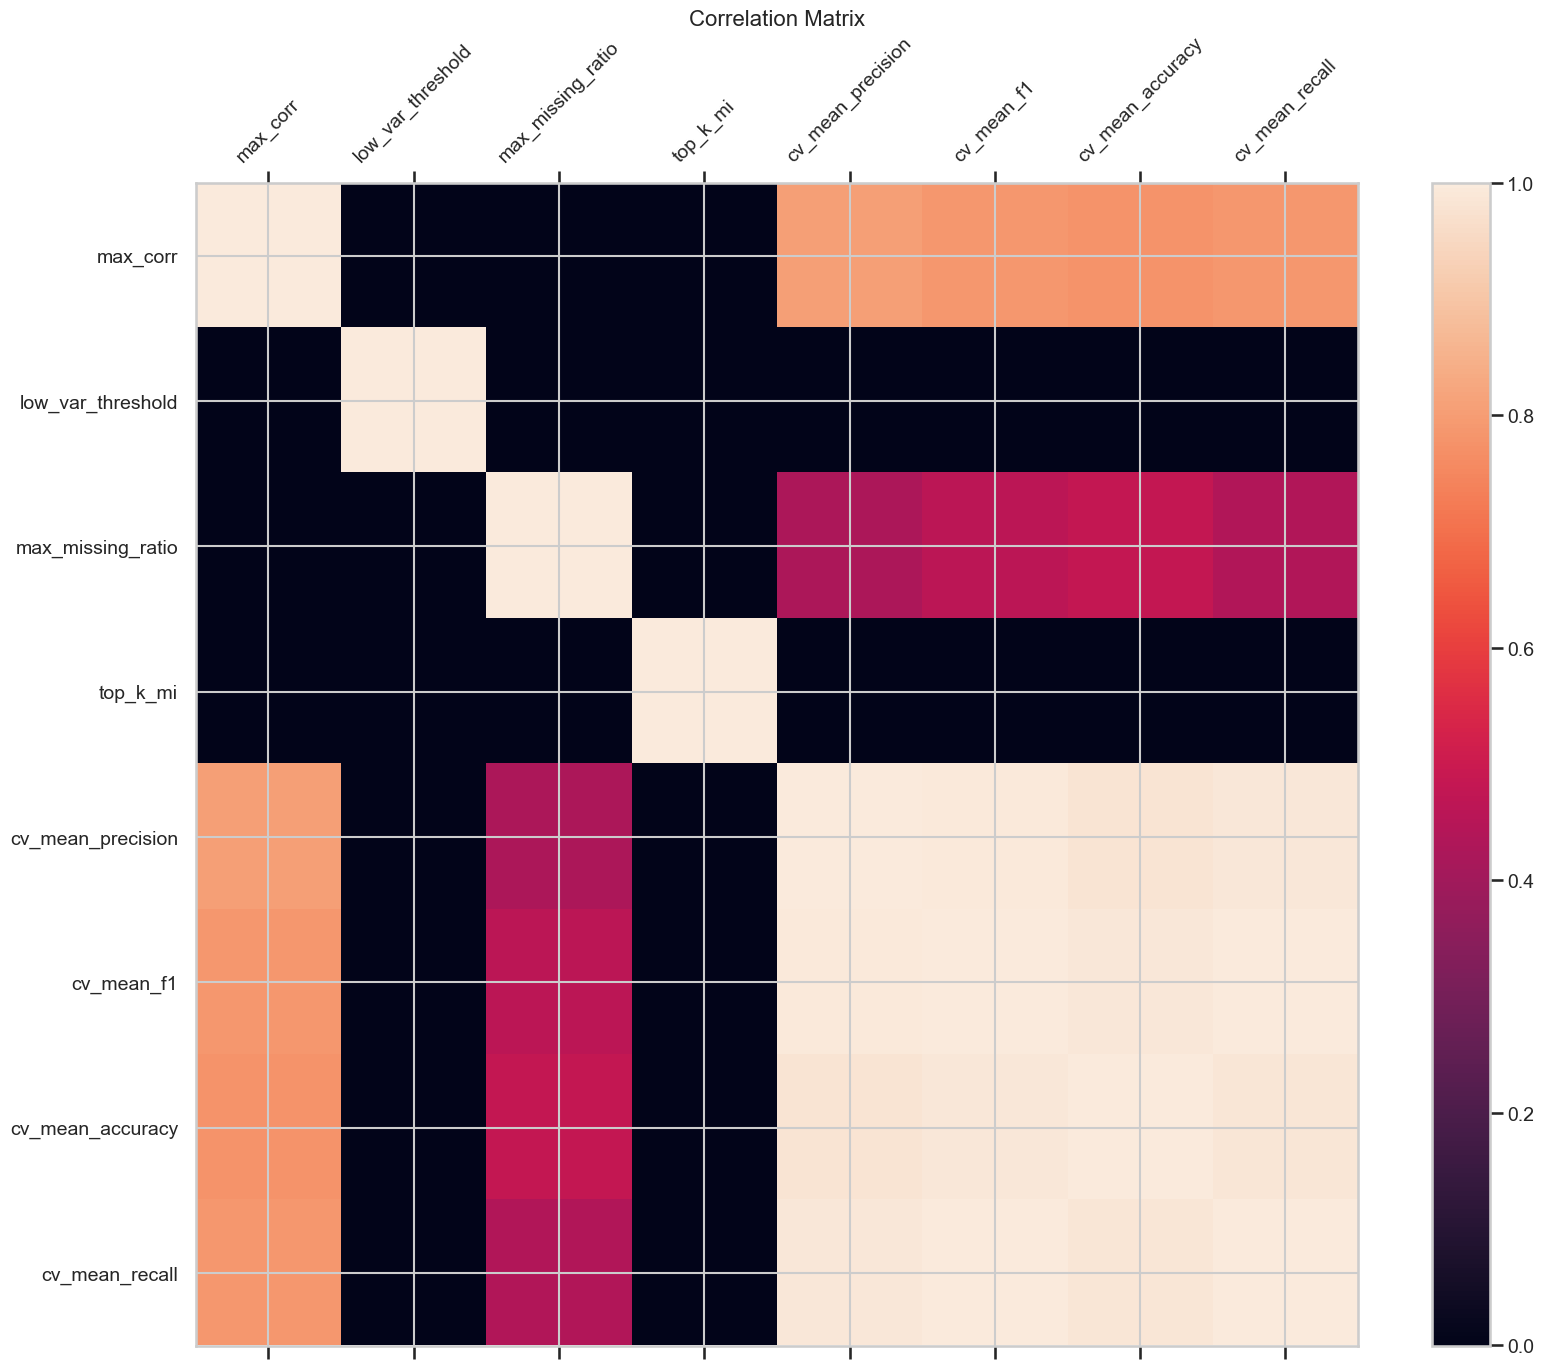

In [ ]:
# Source - https://stackoverflow.com/a/29432741
# Posted by jrjc, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-13, License - CC BY-SA 4.0

f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

In [ ]:
best_runs = client.search_runs(
    experiment_id, order_by=["metrics.cv_mean_accuracy DESC"], max_results=10
)

In [ ]:
best_runs[0]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.1',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '200'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/dd3bfe538f1245b28abfee1f33187d69/artifacts', end_time=1770993179401, experiment_id='378044102522567349', lifecycle_stage='active', run_id='dd3bfe538f1245b28abfee1f33187d69', run_name='logreg_expanding_cv', start_time=1770993178401, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_inp

In [ ]:
best_runs[9]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.001',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '100'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/a8f717ef13654f02ba82b82ada94d1af/artifacts', end_time=1770993106293, experiment_id='378044102522567349', lifecycle_stage='active', run_id='a8f717ef13654f02ba82b82ada94d1af', run_name='logreg_expanding_cv', start_time=1770993104855, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_i

## 3.2 - Parameter Tuning Preprocessor

### 3.2.1 - Run Parameters Cross Validation

In [79]:
mlflow.set_tracking_uri(config.PROJECT_ROOT / 'models/mlruns')
# mlflow.create_experiment('Preprocessor Parameters')
mlflow.set_experiment('Preprocessor Parameters')

MlflowException: Experiment 'Preprocessor Parameters' already exists.

In [ ]:
X = io.load_csv(config.PROCESSED_DATA_DIR / 'X.csv', index_col=0)
y = io.load_csv(config.PROCESSED_DATA_DIR / 'y.csv', index_col=0)

In [ ]:
preprocessor_params_grid = {
    # Numeric Transformer
    # Numeric Imputation
    'num_imputer': {
        'knn': {
            'weights': ['uniform', 'distance'],
            'n_neighbors': [3, 5, 7, 11, 15]
        }, 'uni': {
            'strategy': ['mean', 'median', 'most_frequent', 'constant'],
            'fill_value': [0.0]
        }
    },

    # String Transformer
    'cat': {
        'uni': {
            'strategy': ['most_frequent', 'constant'],
            'fill_value': ['NaN']
        },
        '': {
            '1': [np.nan],
            '2': [np.nan]
        }
    }
}

In [ ]:
model_params = {
    'max_iter': 2000,
    'class_weight': 'balanced'
}

In [80]:
for num_impute, cat_impute in product(
    preprocessor_params_grid['num_imputer'].keys(), preprocessor_params_grid['cat'].keys()
):
    if num_impute == 'knn':
        num_impute_param_1 = 'weights'
        num_impute_param_2 = 'n_neighbors'
    elif num_impute == 'uni':
        num_impute_param_1 = 'strategy'
        num_impute_param_2 = 'fill_value'

    for num_impute_1, num_impute_2 in product(
        preprocessor_params_grid['num_imputer'][num_impute][num_impute_param_1], preprocessor_params_grid['num_imputer'][num_impute][num_impute_param_2]
    ):
        if cat_impute == 'uni':
            cat_impute_param_1 = 'strategy'
            cat_impute_param_2 = 'fill_value'
        elif cat_impute == '':
            cat_impute_param_1 = '1'
            cat_impute_param_2 = '2'

        for cat_impute_1, cat_impute_2 in product(
            preprocessor_params_grid['cat'][cat_impute][cat_impute_param_1], preprocessor_params_grid['cat'][cat_impute][cat_impute_param_2]
        ):
            
            preprocessor_params = {
                'num_imputer': num_impute,
                'num_imputer' + '_' + num_impute + '_' + num_impute_param_1: num_impute_1,
                'num_imputer' + '_' + num_impute + '_' + num_impute_param_2: num_impute_2,
                'cat_imputer': cat_impute,
                'cat_imputer' + '_' + cat_impute + '_' + cat_impute_param_1: cat_impute_1,
                'cat_imputer' + '_' + cat_impute + '_' + cat_impute_param_2: cat_impute_2,
            }
            print(preprocessor_params)
            preprocessor = preprocess_pipeline.build_preprocessor(X, params=preprocessor_params)

            cv_scores = {
                'accuracy': [],
                'precision': [],
                'recall': [],
                'f1': []
            }

            with mlflow.start_run():

                for fold, (train_idx, val_idx) in enumerate(expanding_window_split(df=X, start_year=1999, end_year=2020, val_start_year=2015)):
                    fold_prefix = 'fold_' + str(fold) + '_'
                    
                    X_train, y_train = X.loc[train_idx], y.loc[train_idx, 'OECD_RATING']
                    X_val, y_val = X.loc[val_idx], y.loc[val_idx, 'OECD_RATING']
                    
                    model = model_pipeline.get_model_pipeline('logistic_regression', preprocessor, model_params)
                    model.fit(X_train, y_train)

                    val_fold_results = evaluate.evaluate_model(model, X_val, y_val, prefix=fold_prefix, verbose=False)

                    cv_scores['accuracy'].append(val_fold_results[fold_prefix + 'accuracy'])
                    cv_scores['precision'].append(val_fold_results[fold_prefix + 'precision'])
                    cv_scores['recall'].append(val_fold_results[fold_prefix + 'recall'])
                    cv_scores['f1'].append(val_fold_results[fold_prefix + 'f1'])

                mlflow.log_params(preprocessor_params)
                print(preprocessor_params)
                cv_mean_scores = {'cv_mean_' + k: np.mean(vs) for k, vs in cv_scores.items()}
                print(cv_mean_scores)
                mlflow.log_metrics(cv_mean_scores)

{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'most_frequent', 'cat_imputer_uni_fill_value': 'NaN'}
{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'most_frequent', 'cat_imputer_uni_fill_value': 'NaN'}
{'cv_mean_accuracy': np.float64(0.6765721187987176), 'cv_mean_precision': np.float64(0.6256998026018743), 'cv_mean_recall': np.float64(0.6278051409093127), 'cv_mean_f1': np.float64(0.6160526071099621)}
{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'constant', 'cat_imputer_uni_fill_value': 'NaN'}
{'num_imputer': 'knn', 'num_imputer_knn_weights': 'uniform', 'num_imputer_knn_n_neighbors': 3, 'cat_imputer': 'uni', 'cat_imputer_uni_strategy': 'constant', 'cat_imputer_uni_fill_value': 'NaN'}
{'cv_mean_ac

### 3.2.2 - Analysis

In [81]:
e = mlflow.set_experiment('Preprocessor Parameters')
e.experiment_id

'451170448136544605'

In [82]:
client = mlflow.tracking.MlflowClient()
experiment_id = e.experiment_id

In [83]:
feat_select_runs = client.search_runs(experiment_id)
len(feat_select_runs)

84

In [84]:
rows = []
for run in feat_select_runs:
    run_dict = run.data.to_dictionary()

    row = {}
    for param, v in run_dict['params'].items():
        row[param] = v
    for metric, v in run_dict['metrics'].items():
        row[metric] = v

    rows.append(row)


In [85]:
df = pd.DataFrame(rows)
# df = df.astype(float)
df

,num_imputer_uni_strategy,num_imputer,cat_imputer__1,num_imputer_uni_fill_value,cat_imputer__2,cat_imputer,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall,cat_imputer_uni_fill_value,cat_imputer_uni_strategy,num_imputer_knn_n_neighbors,num_imputer_knn_weights
0,constant,uni,0,0.0,0,,0.576564,0.563009,0.615770,0.574914,NaN,NaN,NaN,NaN
1,most_frequent,uni,0,0.0,0,,0.611258,0.588850,0.639617,0.596491,NaN,NaN,NaN,NaN
2,median,uni,0,0.0,0,,0.595116,0.577006,0.611694,0.581947,NaN,NaN,NaN,NaN
3,mean,uni,0,0.0,0,,0.598830,0.579368,0.610648,0.586899,NaN,NaN,NaN,NaN
4,constant,uni,NaN,0.0,NaN,uni,0.634860,0.628119,0.680648,0.641580,NaN,constant,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,NaN,knn,NaN,NaN,NaN,uni,0.533508,0.514999,0.562928,0.533063,NaN,most_frequent,7,uniform
80,NaN,knn,NaN,NaN,NaN,uni,0.532765,0.514191,0.562011,0.532332,NaN,constant,5,uniform
81,NaN,knn,NaN,NaN,NaN,uni,0.531986,0.513331,0.561088,0.531542,NaN,most_frequent,5,uniform
82,NaN,knn,NaN,NaN,NaN,uni,0.531206,0.512466,0.560149,0.530752,NaN,constant,3,uniform


In [77]:
df.sort_values(by=['cv_mean_f1', 'cv_mean_accuracy'], ascending=False)

,num_imputer_uni_strategy,num_imputer,cat_imputer__1,num_imputer_uni_fill_value,cat_imputer__2,cat_imputer,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall,cat_imputer_uni_fill_value,cat_imputer_uni_strategy,num_imputer_knn_n_neighbors,num_imputer_knn_weights
0,constant,uni,0,0.0,0,,0.552913,0.535676,0.584491,0.551412,NaN,NaN,NaN,NaN
1,most_frequent,uni,0,0.0,0,,0.552759,0.535498,0.584287,0.551259,NaN,NaN,NaN,NaN
2,median,uni,0,0.0,0,,0.552375,0.535148,0.583924,0.550962,NaN,NaN,NaN,NaN
3,mean,uni,0,0.0,0,,0.552093,0.534872,0.583741,0.550757,NaN,NaN,NaN,NaN
4,constant,uni,NaN,0.0,NaN,uni,0.551783,0.534576,0.583562,0.550517,NaN,constant,NaN,NaN
5,constant,uni,NaN,0.0,NaN,uni,0.551227,0.533951,0.582912,0.549908,NaN,most_frequent,NaN,NaN
6,most_frequent,uni,NaN,0.0,NaN,uni,0.550675,0.533328,0.582268,0.549302,NaN,constant,NaN,NaN
7,most_frequent,uni,NaN,0.0,NaN,uni,0.550019,0.532624,0.581594,0.548632,NaN,most_frequent,NaN,NaN
8,median,uni,NaN,0.0,NaN,uni,0.549347,0.531900,0.580898,0.547940,NaN,constant,NaN,NaN
9,median,uni,NaN,0.0,NaN,uni,0.548884,0.531411,0.580398,0.547485,NaN,most_frequent,NaN,NaN


In [ ]:
preprocessor_params = {
    'num_imputer': 'uni',
    'num_imputer_uni_strategy': 'constant',
    'num_imputer_uni_fill_value': 0.0,
    'cat_imputer': ''
}

In [88]:
df.sort_values(by=['cv_mean_f1', 'cv_mean_accuracy'], ascending=False).head(30)

,num_imputer_uni_strategy,num_imputer,cat_imputer__1,num_imputer_uni_fill_value,cat_imputer__2,cat_imputer,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall,cat_imputer_uni_fill_value,cat_imputer_uni_strategy,num_imputer_knn_n_neighbors,num_imputer_knn_weights
7,most_frequent,uni,NaN,0.0,NaN,uni,0.648485,0.638700,0.683606,0.649963,NaN,most_frequent,NaN,NaN
6,most_frequent,uni,NaN,0.0,NaN,uni,0.647396,0.637117,0.681628,0.648113,NaN,constant,NaN,NaN
4,constant,uni,NaN,0.0,NaN,uni,0.634860,0.628119,0.680648,0.641580,NaN,constant,NaN,NaN
5,constant,uni,NaN,0.0,NaN,uni,0.633182,0.626465,0.678622,0.639981,NaN,most_frequent,NaN,NaN
32,NaN,knn,NaN,NaN,NaN,uni,0.640805,0.625007,0.674587,0.632768,NaN,constant,15,uniform
33,NaN,knn,NaN,NaN,NaN,uni,0.638222,0.621378,0.672591,0.627936,NaN,most_frequent,15,uniform
22,NaN,knn,NaN,NaN,NaN,uni,0.626551,0.617278,0.671557,0.625897,NaN,constant,15,distance
35,NaN,knn,NaN,NaN,NaN,uni,0.629699,0.617118,0.671640,0.625505,NaN,most_frequent,11,uniform
23,NaN,knn,NaN,NaN,NaN,uni,0.626020,0.616624,0.671581,0.625655,NaN,most_frequent,15,distance
34,NaN,knn,NaN,NaN,NaN,uni,0.628986,0.616388,0.670630,0.624805,NaN,constant,11,uniform


In [ ]:
preprocessor_params = {
    'num_imputer': 'uni',
    'num_imputer_uni_strategy': 'most_frequent',
    'cat_imputer': 'uni',
    'cat_imputer_uni_strategy': 'most_frequent'
}

### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

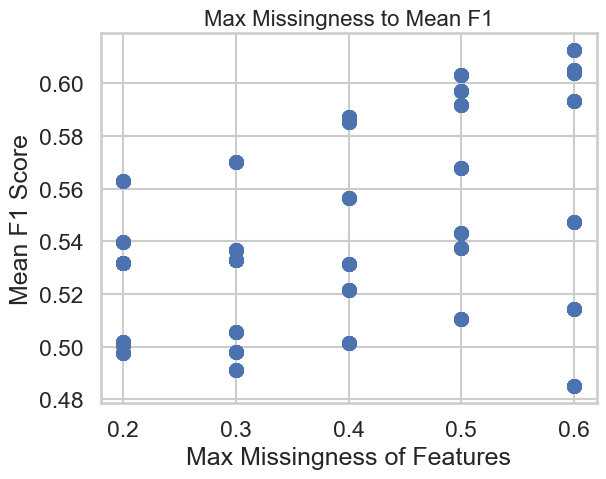

In [ ]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

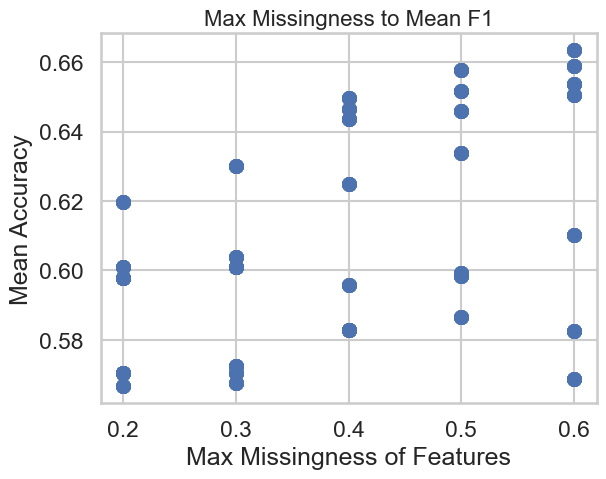

In [119]:
plt.scatter(df['max_missing_ratio'], df['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

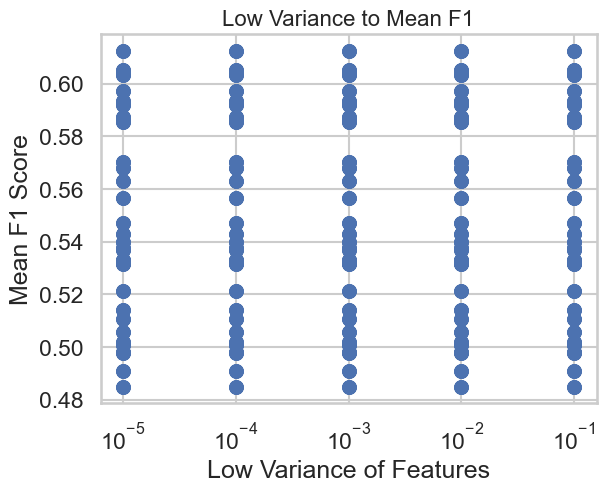

In [ ]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

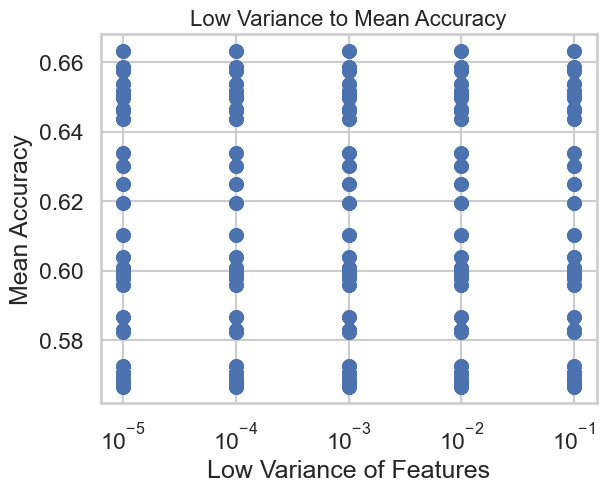

In [124]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df['low_var_threshold'], df['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


### Max Correlation Parameter

Text(0, 0.5, 'Mean F1 Score')

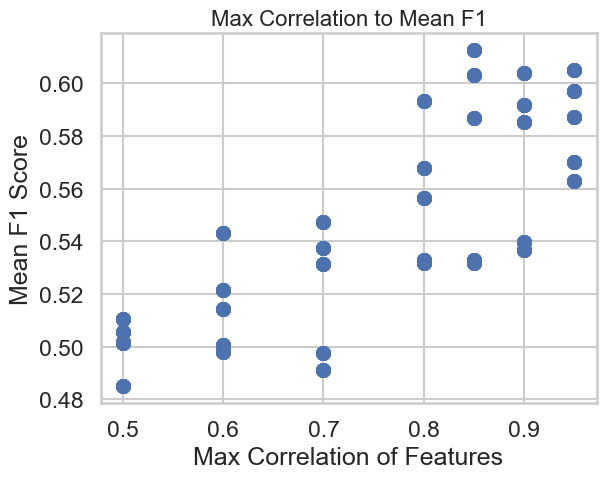

In [115]:
plt.scatter(df['max_corr'], df['cv_mean_f1'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

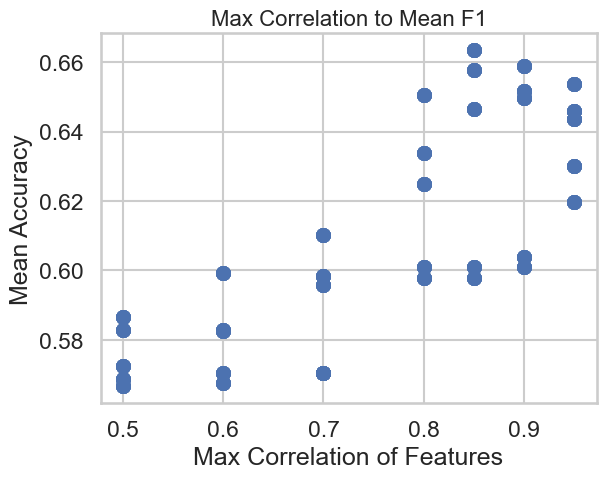

In [116]:
plt.scatter(df['max_corr'], df['cv_mean_accuracy'])
plt.title('Max Correlation to Mean F1', fontsize=16)
plt.xlabel('Max Correlation of Features')
plt.ylabel('Mean Accuracy')

Best max_corr: 0.95

### Set Subset For better View

In [128]:
df_subset = df[df['max_corr'] == 0.95]
df_subset = df_subset.drop(columns=['top_k_mi', 'max_corr']).drop_duplicates()
df_subset

,low_var_threshold,max_missing_ratio,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
0,0.10000,0.6,0.617672,0.605014,0.653633,0.617945
28,0.01000,0.6,0.617672,0.605014,0.653633,0.617945
56,0.00100,0.6,0.617672,0.605014,0.653633,0.617945
84,0.00010,0.6,0.617672,0.605014,0.653633,0.617945
112,0.00001,0.6,0.617672,0.605014,0.653633,0.617945
140,0.10000,0.5,0.612374,0.597240,0.645896,0.610022
168,0.01000,0.5,0.612374,0.597240,0.645896,0.610022
196,0.00100,0.5,0.612374,0.597240,0.645896,0.610022
224,0.00010,0.5,0.612374,0.597240,0.645896,0.610022
252,0.00001,0.5,0.612374,0.597240,0.645896,0.610022


### Max Missing Missingness Ratio 

Text(0, 0.5, 'Mean F1 Score')

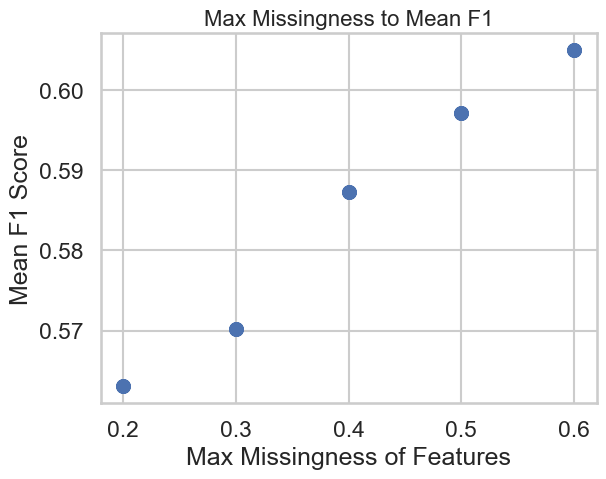

In [129]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_f1'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean F1 Score')

Text(0, 0.5, 'Mean Accuracy')

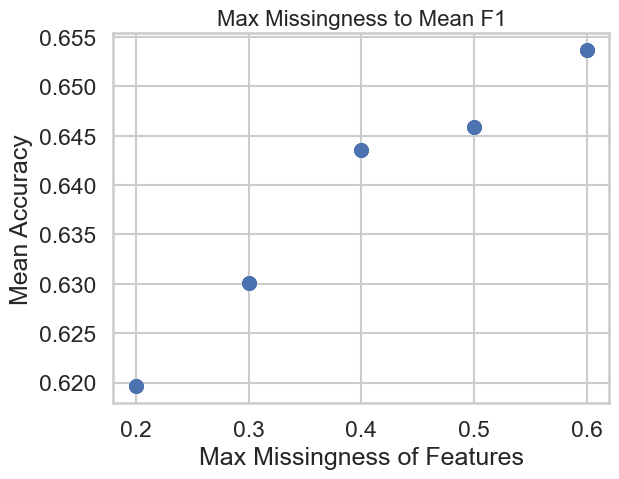

In [130]:
plt.scatter(df_subset['max_missing_ratio'], df_subset['cv_mean_accuracy'])
plt.title('Max Missingness to Mean F1', fontsize=16)
plt.xlabel('Max Missingness of Features')
plt.ylabel('Mean Accuracy')

Best max_missing_ratio: 0.6

### Low Variance Threshold

Text(0, 0.5, 'Mean F1 Score')

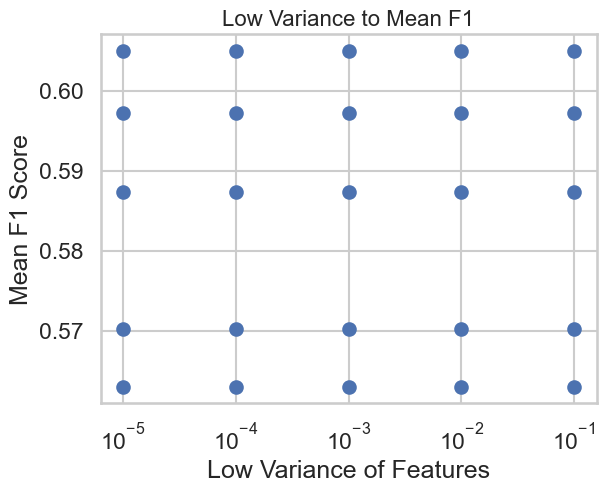

In [131]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_f1'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean F1', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean F1 Score')


Text(0, 0.5, 'Mean Accuracy')

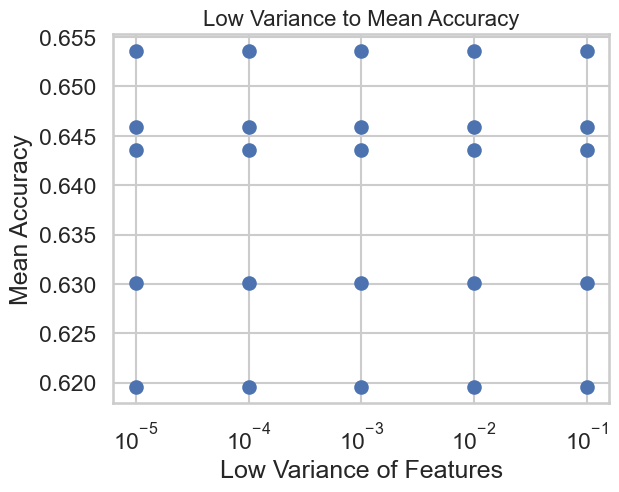

In [132]:
fig = plt.figure()
ax = plt.gca()
ax.scatter(df_subset['low_var_threshold'], df_subset['cv_mean_accuracy'])
ax.set_xscale('log')
ax.set_title('Low Variance to Mean Accuracy', fontsize=16)
ax.set_xlabel('Low Variance of Features')
ax.set_ylabel('Mean Accuracy')


### Max Correlation Parameter

### Correlation

In [104]:
df.corr()

,max_corr,low_var_threshold,max_missing_ratio,top_k_mi,cv_mean_precision,cv_mean_f1,cv_mean_accuracy,cv_mean_recall
max_corr,1.000000e+00,1.187805e-17,-1.346650e-15,2.039939e-17,8.047031e-01,7.852137e-01,7.799878e-01,7.889775e-01
low_var_threshold,1.187805e-17,1.000000e+00,2.191037e-16,1.889756e-16,1.676826e-15,5.705914e-16,3.340624e-15,-2.126166e-15
max_missing_ratio,-1.346650e-15,2.191037e-16,1.000000e+00,6.200501e-16,4.286773e-01,4.620288e-01,4.843349e-01,4.382495e-01
top_k_mi,2.039939e-17,1.889756e-16,6.200501e-16,1.000000e+00,2.401401e-16,2.885995e-16,4.131479e-16,1.910585e-16
cv_mean_precision,8.047031e-01,1.676826e-15,4.286773e-01,2.401401e-16,1.000000e+00,9.944943e-01,9.842894e-01,9.905960e-01
cv_mean_f1,7.852137e-01,5.705914e-16,4.620288e-01,2.885995e-16,9.944943e-01,1.000000e+00,9.894790e-01,9.981645e-01
cv_mean_accuracy,7.799878e-01,3.340624e-15,4.843349e-01,4.131479e-16,9.842894e-01,9.894790e-01,1.000000e+00,9.849867e-01
cv_mean_recall,7.889775e-01,-2.126166e-15,4.382495e-01,1.910585e-16,9.905960e-01,9.981645e-01,9.849867e-01,1.000000e+00


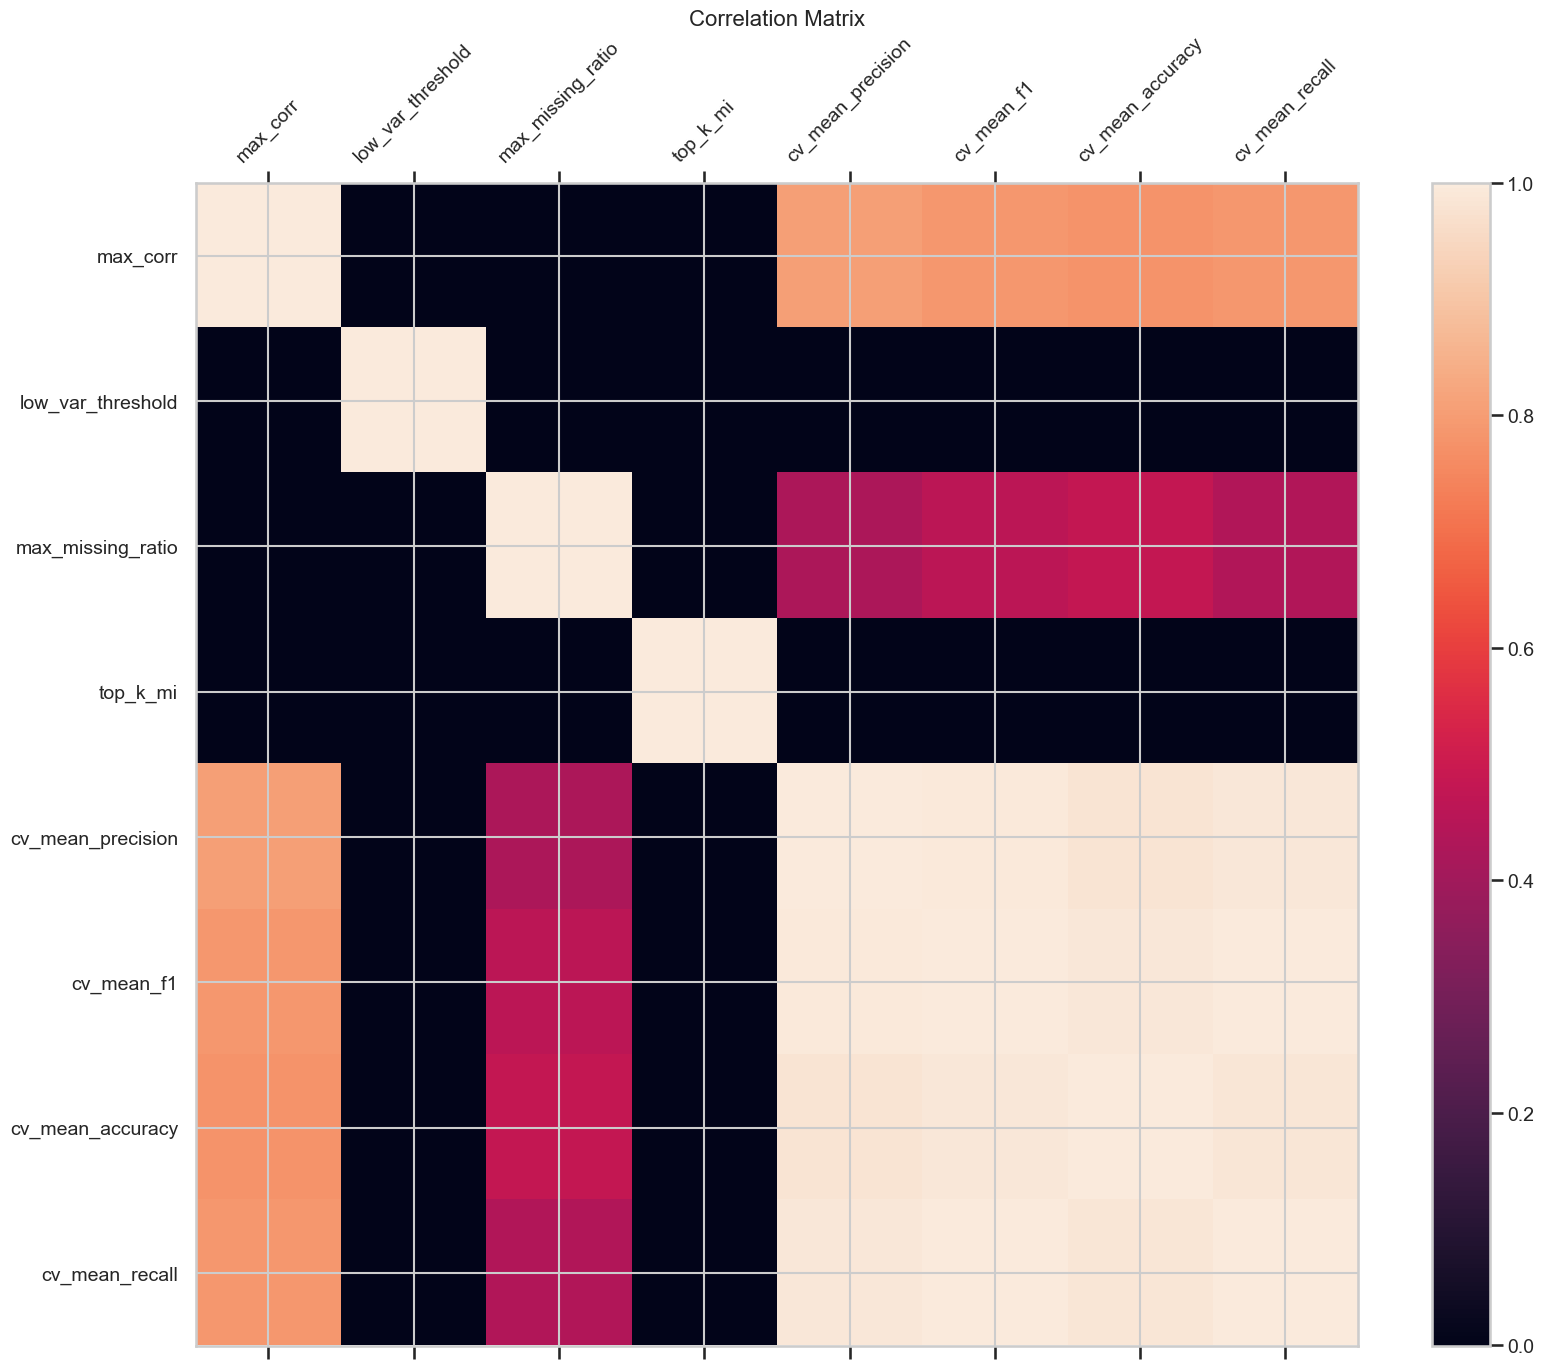

In [107]:
# Source - https://stackoverflow.com/a/29432741
# Posted by jrjc, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-13, License - CC BY-SA 4.0

f = plt.figure(figsize=(19, 15))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


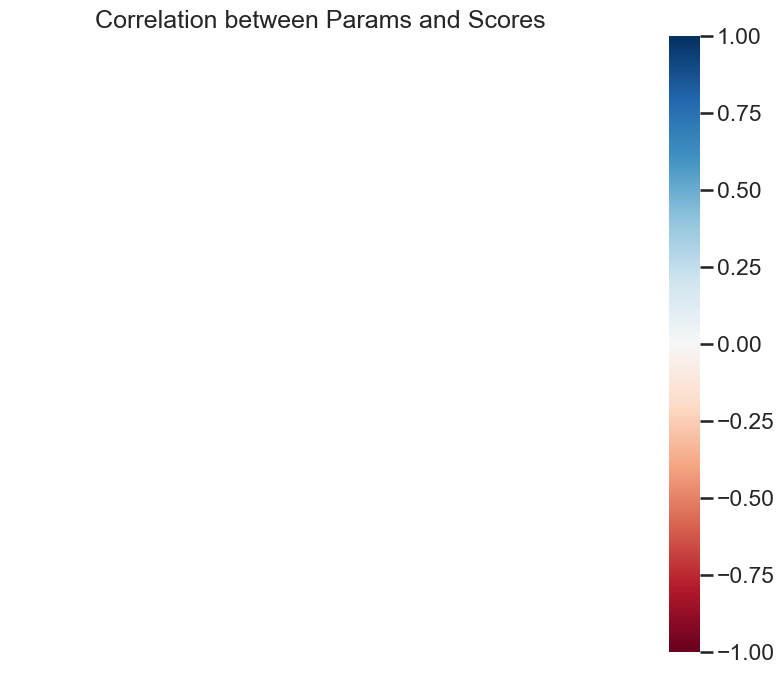

In [ ]:
msno_heatmap(df.corr(), figsize=(10, 8))
plt.title("Correlation between Params and Scores")
plt.show()

In [ ]:
best_runs = client.search_runs(
    experiment_id, order_by=["metrics.cv_mean_accuracy DESC"], max_results=10
)

In [62]:
best_runs[0]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.1',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '200'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/dd3bfe538f1245b28abfee1f33187d69/artifacts', end_time=1770993179401, experiment_id='378044102522567349', lifecycle_stage='active', run_id='dd3bfe538f1245b28abfee1f33187d69', run_name='logreg_expanding_cv', start_time=1770993178401, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_inp

In [64]:
best_runs[9]

<Run: data=<RunData: metrics={'cv_mean_accuracy': 0.6633988738462463,
 'cv_mean_f1': 0.6125989816725145,
 'cv_mean_precision': 0.622142271903296,
 'cv_mean_recall': 0.6308670713298491}, params={'low_var_threshold': '0.001',
 'max_corr': '0.85',
 'max_missing_ratio': '0.6',
 'top_k_mi': '100'}, tags={'mlflow.runName': 'logreg_expanding_cv',
 'mlflow.source.name': '/Users/hippolytegrandet/Desktop/Dev/country_risk_rating/.venv/lib/python3.9/site-packages/ipykernel_launcher.py',
 'mlflow.source.type': 'LOCAL',
 'mlflow.user': 'hippolytegrandet'}>, info=<RunInfo: artifact_uri='file:///Users/hippolytegrandet/Desktop/Dev/country_risk_rating/models/mlruns/378044102522567349/a8f717ef13654f02ba82b82ada94d1af/artifacts', end_time=1770993106293, experiment_id='378044102522567349', lifecycle_stage='active', run_id='a8f717ef13654f02ba82b82ada94d1af', run_name='logreg_expanding_cv', start_time=1770993104855, status='FINISHED', user_id='hippolytegrandet'>, inputs=<RunInputs: dataset_inputs=[], model_i

In [ ]:
!mlflow server --host 127.0.0.1 --port 8080